<a href="https://colab.research.google.com/github/tlinhevg05/contrastive-synthesis-medcls_CVProject/blob/main/01_train_dcgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 - Train DCGAN and Inspect Synthetic Data

Colab notebook for Stage 1 synthetic lung radiography generation. This version keeps the pipeline DCGAN-only because DCGAN is the synthetic source used by the downstream COVID-QU-Syn experiments.


## Before Running
These cells are designed for **Google Colab**.

The real processed data is expected inside the cloned repo:

```text
/content/contrastive-synthesis-medcls_CVProject/data/processed/
├── labelled_4232/
│   ├── COVID/images/
│   ├── Lung_Opacity/images/
│   ├── Viral_Pneumonia/images/
│   └── Normal/images/
└── unlabelled_16934/images/
```

This notebook saves/generated DCGAN synthetic images to Google Drive so they persist after Colab disconnects:

```text
/content/drive/MyDrive/medcls_cvproject/data/processed/synthetic_dcgan/
```

The downstream COVID-QU-Syn experiments consume the registered DCGAN synthetic dataset through:

```text
data/manifests/synthetic_dcgan.csv
```

If DCGAN outputs already exist on Drive, keep `FORCE_RETRAIN = False` so the notebook reuses them instead of overwriting them.


In [1]:
# =========================
# 1. Colab / Drive / Repo setup
# =========================
import os, sys, json, math, random, time, copy, subprocess
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Drive mount skipped:', e)

REPO_URL = "https://github.com/tlinhevg05/contrastive-synthesis-medcls_CVProject.git"
REPO_DIR = Path('/content/contrastive-synthesis-medcls_CVProject')
DRIVE_ROOT = Path('/content/drive/MyDrive/medcls_cvproject')
REPO_DATA_ROOT = REPO_DIR / 'data' / 'processed'
DRIVE_DATA_ROOT = DRIVE_ROOT / 'data' / 'processed'
LABELLED_DATA = REPO_DATA_ROOT / 'labelled_4232'

# Keep the improved run separate from the old Stage 1 outputs until you decide it is better.
OUTPUT_DIR = DRIVE_ROOT / '00_dcgan_stabilized'
SYNTHETIC_DCGAN_OUT = DRIVE_DATA_ROOT / 'synthetic_dcgan_stabilized'
CLASSES = ['COVID', 'Lung_Opacity', 'Viral_Pneumonia', 'Normal']
SEED = 42

# Safe defaults: inspecting/rerunning the notebook will not retrain or overwrite generated images.
# Set RUN_DCGAN_TRAINING=True and RUN_SYNTHETIC_GENERATION=True only when you intentionally rerun Stage 1.
FULL_RUN = True
RUN_DCGAN_TRAINING = False
RUN_SYNTHETIC_GENERATION = False
FORCE_RETRAIN = False
RESUME_TRAINING = True
OVERWRITE_SYNTHETIC = False
COMPUTE_IS_FID = False

# Stabilized DCGAN settings.
# 128x128 keeps more radiographic structure than 64x64 while remaining feasible on Colab/Kaggle GPUs.
IMG_SIZE = 128
NZ = 100
BATCH_SIZE = 64 if FULL_RUN else 16
EPOCHS = 200 if FULL_RUN else 1
LR_G = 2e-4
LR_D = 2e-4
REAL_LABEL_MIN = 0.8
REAL_LABEL_MAX = 1.0
FAKE_LABEL_MAX = 0.1
INSTANCE_NOISE = 0.03
SAMPLE_EVERY = 10
NUM_WORKERS = 0  # Safer in Colab/Kaggle notebooks; avoids DataLoader worker cleanup warnings.
N_SYNTH_PER_CLASS = 1000 if FULL_RUN else 24
GEN_BATCH_SIZE = 64
METRIC_MAX_IMAGES = 2000 if FULL_RUN else 64

DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
DRIVE_DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SYNTHETIC_DCGAN_OUT.mkdir(parents=True, exist_ok=True)

print('Repo labelled data:', LABELLED_DATA)
print('Drive synthetic DCGAN output:', SYNTHETIC_DCGAN_OUT)
print('Stage 1 output/checkpoints:', OUTPUT_DIR)
print('RUN_DCGAN_TRAINING:', RUN_DCGAN_TRAINING)
print('RUN_SYNTHETIC_GENERATION:', RUN_SYNTHETIC_GENERATION)
print('RESUME_TRAINING:', RESUME_TRAINING)
print('COMPUTE_IS_FID:', COMPUTE_IS_FID)

if not REPO_DIR.exists():
    result = subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print('WARNING: repo clone failed. Check repo URL / visibility. Error:')
        print(result.stderr)
else:
    print('Repo already exists:', REPO_DIR)

if REPO_DIR.exists():
    os.chdir(REPO_DIR)
    print('Working directory:', Path.cwd())

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'pip'])
if (REPO_DIR / 'requirements.txt').exists():
    # Colab already has compatible torch/torchvision. Avoid reinstalling pinned CUDA wheels from requirements.txt.
    requirements_path = REPO_DIR / 'requirements.txt'
    filtered_requirements_path = REPO_DIR / 'requirements_colab_filtered.txt'
    skip_prefixes = ('torch', 'torchvision', 'torchaudio', 'triton', 'nvidia-')
    filtered_lines = []
    skipped_lines = []
    for raw_line in requirements_path.read_text().splitlines():
        line = raw_line.strip()
        package_name = line.split('==')[0].split('>=')[0].split('<=')[0].split('~=')[0].lower()
        if not line or line.startswith('#'):
            filtered_lines.append(raw_line)
        elif package_name.startswith(skip_prefixes):
            skipped_lines.append(raw_line)
        else:
            filtered_lines.append(raw_line)
    filtered_requirements_path.write_text('\n'.join(filtered_lines) + '\n')
    print('Skipped Colab runtime packages:', skipped_lines)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(filtered_requirements_path)])
# Some hosted runtimes can end up with a partially incompatible numpy/scipy pair after dependency installs.
# FID uses scipy.linalg.sqrtm, so validate it before moving to the import cell.
try:
    import numpy as _np
    from scipy.linalg import sqrtm as _sqrtm
    print('NumPy/SciPy OK:', _np.__version__)
except Exception as exc:
    print('Repairing NumPy/SciPy installation because import failed:', repr(exc))
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall', '--no-cache-dir',
        'numpy==2.0.2', 'scipy==1.14.1'
    ], check=True)
    print('IMPORTANT: restart the runtime/kernel now, then run the notebook again from the top.')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn', 'pandas', 'tqdm', 'seaborn', 'matplotlib'])


Mounted at /content/drive
Repo labelled data: /content/contrastive-synthesis-medcls_CVProject/data/processed/labelled_4232
Drive synthetic DCGAN output: /content/drive/MyDrive/medcls_cvproject/data/processed/synthetic_dcgan
Stage 1 output/checkpoints: /content/drive/MyDrive/medcls_cvproject/00_gan_compare
RUN_DCGAN_TRAINING: False
RUN_SYNTHETIC_GENERATION: False
COMPUTE_IS_FID: False

Working directory: /content/contrastive-synthesis-medcls_CVProject


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'scikit-learn', 'scipy', 'pandas', 'tqdm', 'seaborn', 'matplotlib'], returncode=0)

In [2]:

# =========================
# 2. Imports, datasets, transforms
# =========================
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils as vutils
from torchvision.models import inception_v3, Inception_V3_Weights
from scipy.linalg import sqrtm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU, running on CPU')
print('Device:', DEVICE)

IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
set_seed(SEED)

def list_images(root):
    root = Path(root)
    if not root.exists():
        return []
    return [p for p in root.rglob('*') if p.suffix.lower() in IMG_EXTS and p.is_file()]

def class_image_dir(root, cls):
    croot = Path(root) / cls
    return croot / 'images' if (croot / 'images').exists() else croot

class ClassImageDataset(Dataset):
    def __init__(self, root, classes, transform=None, selected_class=None, max_per_class=None):
        self.samples = []
        self.classes = classes
        self.transform = transform
        for label, cls in enumerate(classes):
            if selected_class is not None and cls != selected_class:
                continue
            files = sorted(list_images(class_image_dir(root, cls)))
            if max_per_class is not None:
                files = files[:max_per_class]
            self.samples.extend([(p, label) for p in files])
        if not self.samples:
            raise ValueError(f'No images found in {root}')
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

gan_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

for cls in CLASSES:
    print(cls, len(list_images(class_image_dir(LABELLED_DATA, cls))))
assert LABELLED_DATA.exists(), f'Missing labelled data: {LABELLED_DATA}'


Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda
COVID 723
Lung_Opacity 1202
Viral_Pneumonia 269
Normal 2038


In [3]:
# =========================
# 3. DCGAN model
# =========================
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class DCGANGenerator(nn.Module):
    """Standard DCGAN generator for 64x64 or 128x128 images."""
    def __init__(self, nz=100, ngf=64, nc=3, image_size=128):
        super().__init__()
        if image_size not in {64, 128}:
            raise ValueError('IMG_SIZE must be 64 or 128 for this DCGAN architecture.')
        layers = [
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
        ]
        if image_size == 128:
            layers += [
                nn.ConvTranspose2d(ngf, ngf // 2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ngf // 2), nn.ReLU(True),
                nn.ConvTranspose2d(ngf // 2, nc, 4, 2, 1, bias=False),
                nn.Tanh(),
            ]
        else:
            layers += [nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False), nn.Tanh()]
        self.main = nn.Sequential(*layers)

    def forward(self, z):
        return self.main(z)

class DCGANDiscriminator(nn.Module):
    """Standard DCGAN discriminator for 64x64 or 128x128 images."""
    def __init__(self, nc=3, ndf=64, image_size=128):
        super().__init__()
        if image_size not in {64, 128}:
            raise ValueError('IMG_SIZE must be 64 or 128 for this DCGAN architecture.')
        layers = [
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),
        ]
        if image_size == 128:
            layers += [
                nn.Conv2d(ndf * 8, ndf * 8, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),
            ]
        layers += [nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)]
        self.main = nn.Sequential(*layers)

    def forward(self, x):
        return self.main(x).view(-1)


In [4]:
# =========================
# 4. Train or reuse DCGAN checkpoints: one generator per class
# =========================
def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

def save_sample_grid(images, path, nrow=8):
    # Google Drive can briefly fail to see newly-created folders in notebook runtimes.
    # Save locally first, then copy to Drive; sample-save failure should not kill training.
    path = Path(path)
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        tmp_path = Path('/tmp') / path.name
        vutils.save_image(denorm(images.detach().cpu()), str(tmp_path), nrow=nrow)
        shutil.copy2(tmp_path, path)
        tmp_path.unlink(missing_ok=True)
    except Exception as exc:
        print(f'WARNING: could not save sample grid to {path}: {exc}')

def dcgan_checkpoint_path(cls):
    return OUTPUT_DIR / 'checkpoints' / f'dcgan_{cls}_img{IMG_SIZE}.latest.pt'

def dcgan_epoch_checkpoint_path(cls, epoch):
    return OUTPUT_DIR / 'checkpoints' / f'dcgan_{cls}_img{IMG_SIZE}_epoch_{epoch:04d}.pt'

def save_training_checkpoint(path, G, D, optG, optD, epoch, cls, history):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        'epoch': epoch,
        'class': cls,
        'classes': CLASSES,
        'img_size': IMG_SIZE,
        'noise_dim': NZ,
        'G': G.state_dict(),
        'D': D.state_dict(),
        'optG': optG.state_dict(),
        'optD': optD.state_dict(),
        'history': history,
        'settings': {
            'lr_g': LR_G,
            'lr_d': LR_D,
            'batch_size': BATCH_SIZE,
            'real_label_min': REAL_LABEL_MIN,
            'real_label_max': REAL_LABEL_MAX,
            'fake_label_max': FAKE_LABEL_MAX,
            'instance_noise': INSTANCE_NOISE,
        }
    }, path)

def maybe_resume_training(ckpt_path, G, D, optG, optD):
    if not RESUME_TRAINING or FORCE_RETRAIN or not Path(ckpt_path).exists():
        return 0, []
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    if ckpt.get('img_size') != IMG_SIZE:
        print(f"Checkpoint image size mismatch for {ckpt_path}; starting fresh.")
        return 0, []
    G.load_state_dict(ckpt['G'], strict=True)
    D.load_state_dict(ckpt['D'], strict=True)
    if 'optG' in ckpt:
        optG.load_state_dict(ckpt['optG'])
    if 'optD' in ckpt:
        optD.load_state_dict(ckpt['optD'])
    start_epoch = int(ckpt.get('epoch', 0))
    history = list(ckpt.get('history', []))
    print(f'Resumed {ckpt_path} from epoch {start_epoch}')
    return start_epoch, history

def train_dcgan_for_class(cls):
    ckpt_path = dcgan_checkpoint_path(cls)

    if ckpt_path.exists() and not RUN_DCGAN_TRAINING and not FORCE_RETRAIN:
        print('Using existing stabilized DCGAN checkpoint:', ckpt_path)
        return ckpt_path

    if not RUN_DCGAN_TRAINING:
        print(f'Skipping DCGAN training for {cls}. No checkpoint found at: {ckpt_path}')
        return None

    dataset = ClassImageDataset(LABELLED_DATA, CLASSES, transform=gan_tf, selected_class=cls, max_per_class=None if FULL_RUN else 64)
    loader = DataLoader(
        dataset,
        batch_size=min(BATCH_SIZE, len(dataset)),
        shuffle=True,
        num_workers=NUM_WORKERS,
        drop_last=True,
        pin_memory=(DEVICE.type == 'cuda'),
    )
    G = DCGANGenerator(NZ, image_size=IMG_SIZE).to(DEVICE).apply(weights_init)
    D = DCGANDiscriminator(image_size=IMG_SIZE).to(DEVICE).apply(weights_init)
    optG = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    start_epoch, history = maybe_resume_training(ckpt_path, G, D, optG, optD)
    fixed_noise = torch.randn(32, NZ, 1, 1, device=DEVICE)

    print(f'Training {cls}: {len(dataset)} real images, start_epoch={start_epoch}, target_epochs={EPOCHS}')
    for epoch in range(start_epoch, EPOCHS):
        g_losses, d_losses = [], []
        for real, _ in tqdm(loader, desc=f'DCGAN {cls} epoch {epoch+1}/{EPOCHS}'):
            real = real.to(DEVICE, non_blocking=True)
            b = real.size(0)

            real_targets = torch.empty(b, device=DEVICE).uniform_(REAL_LABEL_MIN, REAL_LABEL_MAX)
            fake_targets = torch.empty(b, device=DEVICE).uniform_(0.0, FAKE_LABEL_MAX)

            z = torch.randn(b, NZ, 1, 1, device=DEVICE)
            fake = G(z).detach()

            noise_scale = INSTANCE_NOISE * max(0.0, 1.0 - epoch / max(1, EPOCHS))
            if noise_scale > 0:
                real_for_d = (real + torch.randn_like(real) * noise_scale).clamp(-1, 1)
                fake_for_d = (fake + torch.randn_like(fake) * noise_scale).clamp(-1, 1)
            else:
                real_for_d, fake_for_d = real, fake

            d_real = criterion(D(real_for_d), real_targets)
            d_fake = criterion(D(fake_for_d), fake_targets)
            d_loss = d_real + d_fake
            optD.zero_grad(set_to_none=True)
            d_loss.backward()
            optD.step()
            d_losses.append(d_loss.item())

            z = torch.randn(b, NZ, 1, 1, device=DEVICE)
            fake = G(z)
            g_loss = criterion(D(fake), torch.ones(b, device=DEVICE))
            optG.zero_grad(set_to_none=True)
            g_loss.backward()
            optG.step()
            g_losses.append(g_loss.item())

        row = {'epoch': epoch+1, 'class': cls, 'g_loss': float(np.mean(g_losses)), 'd_loss': float(np.mean(d_losses))}
        history.append(row)
        print(row)

        save_training_checkpoint(ckpt_path, G, D, optG, optD, epoch + 1, cls, history)
        if (epoch + 1) % SAMPLE_EVERY == 0 or epoch == start_epoch:
            save_training_checkpoint(dcgan_epoch_checkpoint_path(cls, epoch + 1), G, D, optG, optD, epoch + 1, cls, history)
            save_sample_grid(G(fixed_noise), OUTPUT_DIR / 'samples' / cls / f'epoch_{epoch+1:04d}.png')

    pd.DataFrame(history).to_csv(OUTPUT_DIR / f'dcgan_{cls}_history.csv', index=False)
    print('Saved latest checkpoint:', ckpt_path)
    return ckpt_path

DCGAN_CKPTS = {}
for cls in CLASSES:
    DCGAN_CKPTS[cls] = train_dcgan_for_class(cls)
print('DCGAN_CKPTS:', DCGAN_CKPTS)


Using existing DCGAN checkpoint: /content/drive/MyDrive/medcls_cvproject/00_gan_compare/checkpoints/repo_dcgan_COVID.latest.pt
Using existing DCGAN checkpoint: /content/drive/MyDrive/medcls_cvproject/00_gan_compare/checkpoints/repo_dcgan_Lung_Opacity.latest.pt
Using existing DCGAN checkpoint: /content/drive/MyDrive/medcls_cvproject/00_gan_compare/checkpoints/repo_dcgan_Viral_Pneumonia.latest.pt
Using existing DCGAN checkpoint: /content/drive/MyDrive/medcls_cvproject/00_gan_compare/checkpoints/repo_dcgan_Normal.latest.pt
DCGAN_CKPTS: {'COVID': PosixPath('/content/drive/MyDrive/medcls_cvproject/00_gan_compare/checkpoints/repo_dcgan_COVID.latest.pt'), 'Lung_Opacity': PosixPath('/content/drive/MyDrive/medcls_cvproject/00_gan_compare/checkpoints/repo_dcgan_Lung_Opacity.latest.pt'), 'Viral_Pneumonia': PosixPath('/content/drive/MyDrive/medcls_cvproject/00_gan_compare/checkpoints/repo_dcgan_Viral_Pneumonia.latest.pt'), 'Normal': PosixPath('/content/drive/MyDrive/medcls_cvproject/00_gan_compare

## DCGAN-Only Stage 1

This notebook keeps Stage 1 focused on DCGAN because DCGAN is the selected synthetic source for downstream COVID-QU-Syn experiments.

By default, this notebook is safe to rerun: it does not train DCGAN again and does not regenerate synthetic images. To intentionally retrain, set `RUN_DCGAN_TRAINING = True`. To intentionally regenerate images, set `RUN_SYNTHETIC_GENERATION = True`.


In [5]:
# =========================
# 5. Generate or reuse DCGAN synthetic dataset
# =========================
def save_pil_tensor(img_tensor, path):
    img = denorm(img_tensor).detach().cpu()
    pil = transforms.ToPILImage()(img)
    path.parent.mkdir(parents=True, exist_ok=True)
    pil.save(path)

def extract_generator_state(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ['G', 'generator', 'generator_state_dict', 'model_state_dict', 'state_dict']:
            if key in checkpoint and isinstance(checkpoint[key], dict):
                return checkpoint[key]
    return checkpoint

def load_dcgan_generator(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    if isinstance(checkpoint, dict) and checkpoint.get('img_size') not in (None, IMG_SIZE):
        raise ValueError(f"Checkpoint IMG_SIZE mismatch: {checkpoint.get('img_size')} != {IMG_SIZE}")
    state = extract_generator_state(checkpoint)
    cleaned = {}
    for key, value in state.items():
        new_key = key
        for prefix in ['module.', 'generator.', 'G.']:
            if new_key.startswith(prefix):
                new_key = new_key[len(prefix):]
        cleaned[new_key] = value
    G = DCGANGenerator(NZ, image_size=IMG_SIZE).to(DEVICE)
    G.load_state_dict(cleaned, strict=True)
    G.eval()
    return G

def generate_dcgan_dataset():
    if not RUN_SYNTHETIC_GENERATION:
        print('RUN_SYNTHETIC_GENERATION=False; keeping existing synthetic DCGAN images.')
        return

    for cls in CLASSES:
        out_dir = SYNTHETIC_DCGAN_OUT / cls / 'images'
        out_dir.mkdir(parents=True, exist_ok=True)
        existing = len(list_images(out_dir))
        if existing >= N_SYNTH_PER_CLASS and not OVERWRITE_SYNTHETIC:
            print(f'DCGAN synthetic exists for {cls}: {existing}')
            continue
        if OVERWRITE_SYNTHETIC:
            for image_path in list_images(out_dir):
                image_path.unlink()

        ckpt_path = DCGAN_CKPTS.get(cls)
        if ckpt_path is None or not Path(ckpt_path).exists():
            print(f'WARNING: no DCGAN checkpoint for {cls}; cannot generate this class.')
            continue

        G = load_dcgan_generator(ckpt_path)
        for start in tqdm(range(0, N_SYNTH_PER_CLASS, GEN_BATCH_SIZE), desc=f'Generate DCGAN {cls}'):
            batch_size = min(GEN_BATCH_SIZE, N_SYNTH_PER_CLASS - start)
            z = torch.randn(batch_size, NZ, 1, 1, device=DEVICE)
            with torch.no_grad():
                images = G(z)
            for offset, img in enumerate(images):
                save_pil_tensor(img, out_dir / f'dcgan_{cls}_{start + offset:05d}.png')

generate_dcgan_dataset()
print('DCGAN synthetic root:', SYNTHETIC_DCGAN_OUT)
for cls in CLASSES:
    print(cls, len(list_images(class_image_dir(SYNTHETIC_DCGAN_OUT, cls))))
print('Total DCGAN synthetic images:', len(list_images(SYNTHETIC_DCGAN_OUT)))


RUN_SYNTHETIC_GENERATION=False; keeping existing synthetic DCGAN images.
DCGAN synthetic root: /content/drive/MyDrive/medcls_cvproject/data/processed/synthetic_dcgan
COVID 1000
Lung_Opacity 1000
Viral_Pneumonia 1000
Normal 1000
Total DCGAN synthetic images: 4000


Saved sample grid: /content/drive/MyDrive/medcls_cvproject/00_gan_compare/samples/dcgan_synthetic_grid.png


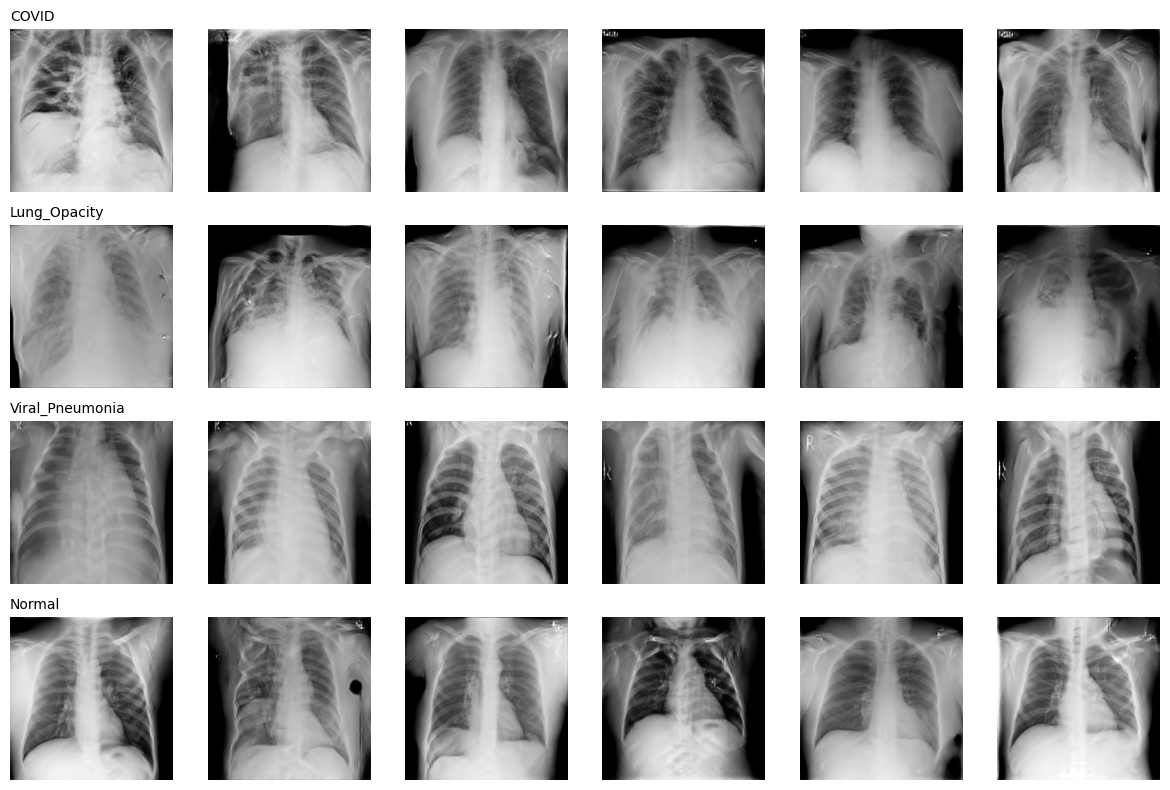

COMPUTE_IS_FID=False; displaying saved metric tables if available.
Existing metric artifact: /content/drive/MyDrive/medcls_cvproject/00_gan_compare/gan_fid_summary.csv


,model,class,fid
0,repo_DCGAN,COVID,111.770434
1,repo_DCGAN,Lung_Opacity,97.701684
2,repo_DCGAN,Normal,80.188019
3,repo_DCGAN,Viral_Pneumonia,81.552375


Existing metric artifact: /content/drive/MyDrive/medcls_cvproject/00_gan_compare/gan_metrics_average.csv


,model,real_images,generated_images,fid,is_mean,is_std
0,DCGAN,4232,4000,92.804531,1.968337,0.077938


Existing metric artifact: /content/drive/MyDrive/medcls_cvproject/00_gan_compare/gan_metrics_by_class.csv


,model,class,real_images,generated_images,fid,is_mean,is_std
0,DCGAN,COVID,723,1000,111.772714,2.046132,0.097199
1,DCGAN,Lung_Opacity,1202,1000,97.702108,2.004110,0.064197
2,DCGAN,Normal,2038,1000,80.188551,2.038776,0.084475
3,DCGAN,Viral_Pneumonia,269,1000,81.554750,1.784331,0.065882


Existing metric artifact: /content/drive/MyDrive/medcls_cvproject/results/stage1_synthesis/synthetic_summary.json


,generator,source,synthetic_dir,manifest_path,metadata_path,sample_grid_path,total_images,class_counts.COVID,class_counts.Lung_Opacity,class_counts.Viral_Pneumonia,class_counts.Normal
0,DCGAN,stage1_synthesis,/content/drive/.shortcut-targets-by-id/1xMFR7H...,/content/drive/MyDrive/medcls_cvproject/data/m...,/content/drive/MyDrive/medcls_cvproject/result...,/content/drive/MyDrive/medcls_cvproject/result...,4000,1000,1000,1000,1000


DONE. Use this DCGAN path for COVID-QU-Syn classification runs:
/content/drive/MyDrive/medcls_cvproject/data/processed/synthetic_dcgan


In [6]:
# =========================
# 6. Display DCGAN samples and compute synthetic quality metrics
# =========================
def display_samples_by_class(root, classes, samples_per_class=6):
    rows = []
    titles = []
    for cls in classes:
        files = sorted(list_images(class_image_dir(root, cls)))[:samples_per_class]
        for p in files:
            rows.append(Image.open(p).convert('RGB'))
            titles.append(cls)
    if not rows:
        print('No synthetic DCGAN images found at:', root)
        return
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 2.0, len(classes) * 2.0))
    axes = np.array(axes).reshape(len(classes), samples_per_class)
    idx = 0
    for r, cls in enumerate(classes):
        files = sorted(list_images(class_image_dir(root, cls)))[:samples_per_class]
        for c in range(samples_per_class):
            ax = axes[r, c]
            ax.axis('off')
            if c < len(files):
                ax.imshow(Image.open(files[c]).convert('RGB'), cmap='gray')
            if c == 0:
                ax.set_title(cls, loc='left', fontsize=10)
    plt.tight_layout()
    sample_grid_path = OUTPUT_DIR / 'samples' / 'dcgan_synthetic_grid.png'
    sample_grid_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(sample_grid_path, dpi=160, bbox_inches='tight')
    print('Saved sample grid:', sample_grid_path)
    plt.show()

display_samples_by_class(SYNTHETIC_DCGAN_OUT, CLASSES, samples_per_class=6)

class ImageOnlyDataset(Dataset):
    def __init__(self, root, transform, max_images=None):
        self.files = sorted(list_images(root))
        if max_images is not None:
            self.files = self.files[:max_images]
        self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        return self.transform(img)

@torch.no_grad()
def inception_features(root, max_images=1000):
    weights = Inception_V3_Weights.DEFAULT
    tf = weights.transforms()
    ds = ImageOnlyDataset(root, tf, max_images=max_images)
    if len(ds) == 0:
        raise ValueError(f'No images found for metric computation: {root}')
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    model = inception_v3(weights=weights)
    model.fc = nn.Identity()
    model.eval().to(DEVICE)
    feats = []
    for x in tqdm(loader, desc=f'features {Path(root).name}'):
        x = x.to(DEVICE)
        feats.append(model(x).detach().cpu().numpy())
    return np.concatenate(feats, axis=0)

def fid_from_features(real_feats, fake_feats):
    mu1, sigma1 = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))

@torch.no_grad()
def inception_score(root, max_images=1000, splits=10):
    weights = Inception_V3_Weights.DEFAULT
    tf = weights.transforms()
    ds = ImageOnlyDataset(root, tf, max_images=max_images)
    if len(ds) == 0:
        raise ValueError(f'No images found for metric computation: {root}')
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    model = inception_v3(weights=weights)
    model.eval().to(DEVICE)
    probs = []
    for x in tqdm(loader, desc=f'IS {Path(root).name}'):
        x = x.to(DEVICE)
        probs.append(F.softmax(model(x), dim=1).detach().cpu().numpy())
    probs = np.concatenate(probs, axis=0)
    scores = []
    for part in np.array_split(probs, min(splits, len(probs))):
        py = part.mean(axis=0, keepdims=True)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        scores.append(np.exp(kl.sum(axis=1).mean()))
    return float(np.mean(scores)), float(np.std(scores))

def display_existing_dcgan_metrics():
    candidate_paths = [
        OUTPUT_DIR / 'dcgan_quality_metrics.csv',
        OUTPUT_DIR / 'gan_comparison_metrics.csv',
        OUTPUT_DIR / 'gan_fid_summary.csv',
        OUTPUT_DIR / 'gan_metrics_average.csv',
        OUTPUT_DIR / 'gan_metrics_by_class.csv',
        DRIVE_ROOT / 'results' / 'stage1_synthesis' / 'synthetic_summary.json',
    ]
    found = False
    for metrics_path in candidate_paths:
        if not metrics_path.exists():
            continue
        found = True
        print('Existing metric artifact:', metrics_path)
        if metrics_path.suffix.lower() == '.csv':
            df = pd.read_csv(metrics_path)
            if 'model' in df.columns:
                df = df[df['model'].astype(str).str.upper().str.contains('DCGAN', na=False)].copy()
            if df.empty:
                print('  No DCGAN rows in this artifact; skipping display.')
                continue
            display(df.reset_index(drop=True))
        elif metrics_path.suffix.lower() == '.json':
            with open(metrics_path) as f:
                payload = json.load(f)
            df = pd.json_normalize(payload)
            if 'model' in df.columns:
                df = df[df['model'].astype(str).str.upper().str.contains('DCGAN', na=False)].copy()
            if df.empty:
                print('  No DCGAN rows in this artifact; skipping display.')
                continue
            display(df.reset_index(drop=True))
    if not found:
        print('No saved IS/FID metric table found. Set COMPUTE_IS_FID=True to compute it.')

if COMPUTE_IS_FID:
    # Global metric: all real labelled images vs all generated DCGAN images.
    real_feats = inception_features(LABELLED_DATA, max_images=METRIC_MAX_IMAGES)
    fake_feats = inception_features(SYNTHETIC_DCGAN_OUT, max_images=METRIC_MAX_IMAGES)
    fid = fid_from_features(real_feats, fake_feats)
    is_mean, is_std = inception_score(SYNTHETIC_DCGAN_OUT, max_images=METRIC_MAX_IMAGES)
    average_results = pd.DataFrame([{
        'model': 'DCGAN',
        'real_images': len(list_images(LABELLED_DATA)),
        'generated_images': len(list_images(SYNTHETIC_DCGAN_OUT)),
        'fid': fid,
        'is_mean': is_mean,
        'is_std': is_std,
    }])
    average_path = OUTPUT_DIR / 'gan_metrics_average.csv'
    average_results.to_csv(average_path, index=False)
    print('Saved global metrics:', average_path)
    display(average_results)

    # Per-class metric: each real class folder vs its generated class folder.
    by_class_rows = []
    for cls in CLASSES:
        real_dir = class_image_dir(LABELLED_DATA, cls)
        fake_dir = class_image_dir(SYNTHETIC_DCGAN_OUT, cls)
        real_cls_feats = inception_features(real_dir, max_images=METRIC_MAX_IMAGES)
        fake_cls_feats = inception_features(fake_dir, max_images=METRIC_MAX_IMAGES)
        cls_fid = fid_from_features(real_cls_feats, fake_cls_feats)
        cls_is_mean, cls_is_std = inception_score(fake_dir, max_images=METRIC_MAX_IMAGES)
        by_class_rows.append({
            'model': 'DCGAN',
            'class': cls,
            'real_images': len(list_images(real_dir)),
            'generated_images': len(list_images(fake_dir)),
            'fid': cls_fid,
            'is_mean': cls_is_mean,
            'is_std': cls_is_std,
        })
    by_class_results = pd.DataFrame(by_class_rows)
    by_class_path = OUTPUT_DIR / 'gan_metrics_by_class.csv'
    by_class_results.to_csv(by_class_path, index=False)
    print('Saved per-class metrics:', by_class_path)
    display(by_class_results)
else:
    print('COMPUTE_IS_FID=False; displaying saved metric tables if available.')
    display_existing_dcgan_metrics()

print('DONE. Use this DCGAN path for COVID-QU-Syn classification runs:')
print(SYNTHETIC_DCGAN_OUT)
